# Dataset USC-HAD

In [26]:
import pandas as pd
import numpy as np
import json
import os
import scipy.io

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

In [27]:
# Directorio base donde se encuentran las carpetas Subject1, Subject2, ...
base_directory = 'Old Datasets/USC-HAD'

# Lista para almacenar los DataFrames de cada archivo .mat
dfs = []

# Función para buscar la clave relacionada con 'activity_number'
def find_activity_number_key(data):
    possible_keys = ['activity_number', 'activity_numbr']  # Posibles nombres de clave
    
    for key in possible_keys:
        if key in data:
            return key
    
    return None

# Recorrer las carpetas Subject1, Subject2, ...
for subject_folder in os.listdir(base_directory):
    subject_path = os.path.join(base_directory, subject_folder)
    
    if os.path.isdir(subject_path):
        # Recorrer los archivos .mat dentro de la carpeta del sujeto
        for filename in os.listdir(subject_path):
            if filename.endswith('.mat'):
                file_path = os.path.join(subject_path, filename)
                
                # Cargar el archivo .mat
                data = scipy.io.loadmat(file_path)
                
                # Buscar la clave relacionada con 'activity_number'
                activity_number_key = find_activity_number_key(data)
                
                # Obtener los datos y las cabeceras
                sensor_readings = data['sensor_readings']
                
                # Crear un DataFrame
                df = pd.DataFrame(sensor_readings, columns=cabeceras)
                
                # Agregar la columna "activity" con el valor "activity_number"
                if activity_number_key is not None:
                    activity_number = int(data[activity_number_key][0])
                    df['activity'] = activity_number
                
                # Agregar el DataFrame a la lista
                dfs.append(df)

# Combinar todos los DataFrames en uno solo
users = pd.concat(dfs, ignore_index=True)

print("Datos combinados y guardados exitosamente.")
users.info()

Datos combinados y guardados exitosamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811490 entries, 0 to 2811489
Data columns (total 7 columns):
 #   Column    Dtype  
---  ------    -----  
 0   acc_x     float64
 1   acc_y     float64
 2   acc_z     float64
 3   gyro_x    float64
 4   gyro_y    float64
 5   gyro_z    float64
 6   activity  int64  
dtypes: float64(6), int64(1)
memory usage: 150.1 MB


In [28]:
users.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity
0,0.864040,0.534541,-0.072511,-0.030473,0.376900,0.078035,8
1,0.867473,0.534541,-0.072511,-0.030381,-0.427444,0.077793,8
2,0.867473,0.534541,-0.068851,-0.030289,-0.024536,-0.324030,8
3,0.867473,0.534541,-0.076171,-0.030197,0.377130,0.078557,8
4,0.867473,0.534541,-0.072511,-0.030106,0.375969,0.078313,8


#### Calculo de valores no nulos

In [30]:
# Agrupar por la columna "activity" y calcular el número de datos no nulos por columna
counts = users.groupby("activity").count()

# Calcular la suma de valores nulos por columna
null_counts = users.groupby("activity").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
activity,,,,,,
1,381400,381400,381400,381400,381400,381400
2,264600,264600,264600,264600,264600,264600
3,269700,269700,269700,269700,269700,269700
4,211800,211800,211800,211800,211800,211800
5,197400,197400,197400,197400,197400,197400
6,176500,176500,176500,176500,176500,176500
7,107100,107100,107100,107100,107100,107100
8,261500,261500,261500,261500,261500,261500
9,236000,236000,236000,236000,236000,236000


# Preparación de los datos

#### Comprobación de las columnas del sensor Acelerómetro

In [32]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
users[['acc_x', 'acc_y', 'acc_z']] = users[['acc_x', 'acc_y', 'acc_z']].apply(lambda x: x.interpolate().fillna(method='bfill'))
users.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity
0,0.864040,0.534541,-0.072511,-0.030473,0.376900,0.078035,8
1,0.867473,0.534541,-0.072511,-0.030381,-0.427444,0.077793,8
2,0.867473,0.534541,-0.068851,-0.030289,-0.024536,-0.324030,8
3,0.867473,0.534541,-0.076171,-0.030197,0.377130,0.078557,8
4,0.867473,0.534541,-0.072511,-0.030106,0.375969,0.078313,8


In [33]:
cantidad_nulos = users[['acc_x', 'acc_y', 'acc_z']].isnull().sum()
print(cantidad_nulos)

acc_x    0
acc_y    0
acc_z    0
dtype: int64


#### Comprobación de las columnas del sensor Giroscopio

In [34]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
users[['gyro_x', 'gyro_y', 'gyro_z']] = users[['gyro_x', 'gyro_y', 'gyro_z']].apply(lambda x: x.interpolate().fillna(method='bfill'))
users.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity
0,0.864040,0.534541,-0.072511,-0.030473,0.376900,0.078035,8
1,0.867473,0.534541,-0.072511,-0.030381,-0.427444,0.077793,8
2,0.867473,0.534541,-0.068851,-0.030289,-0.024536,-0.324030,8
3,0.867473,0.534541,-0.076171,-0.030197,0.377130,0.078557,8
4,0.867473,0.534541,-0.072511,-0.030106,0.375969,0.078313,8


In [35]:
cantidad_nulos = users[['gyro_x', 'gyro_y', 'gyro_z']].isnull().sum()
print(cantidad_nulos)

gyro_x    0
gyro_y    0
gyro_z    0
dtype: int64


#### Número de valores de cada Actividad

In [38]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = users['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

1     381400
10    375000
3     269700
2     264600
8     261500
9     236000
4     211800
5     197400
6     176500
11    165491
12    164999
7     107100
Name: activity, dtype: int64


Procedemos a unificar los 3 valores de caminar en valor 1: 
- Walking Forward => 1
- Walking Left => 2
- Walking Right => 3 

Y los 2 valores de subir y bajar escaleras en el valor 2:
- Walinkg Upstairs => 4
- Walinkg Downstairs => 5

In [39]:
change = {2:1, 3:1, 4:2, 5:2}
users['activity'] = users['activity'].replace(change)

Filtramos por estos valores:

In [40]:
user1 = users.loc[(users["activity"] == 1) | (users["activity"] == 2)]

Vemos el número de datos que al final nos quedan de estas dos actividades:

In [42]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = user1['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

1    915700
2    409200
Name: activity, dtype: int64


# Correlación de datos

In [44]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity    1.000000
acc_y       0.057363
acc_x       0.020468
acc_z       0.013442
gyro_x      0.006592
gyro_z      0.006508
gyro_y      0.002024
Name: activity, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

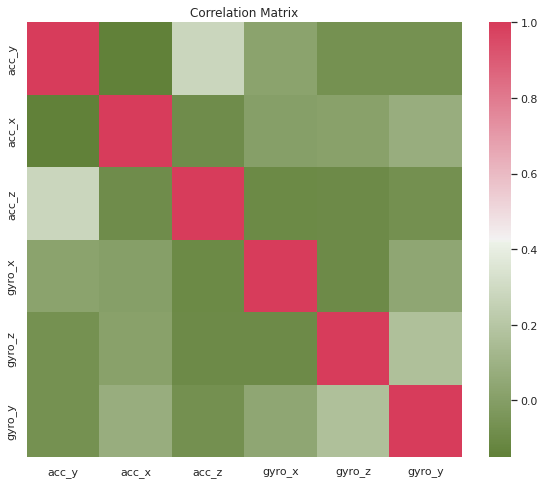

In [45]:
# Correlation matrix
CorrInfo = pd.DataFrame(user1,columns=['acc_y','acc_x', 'acc_z', 'gyro_x', 'gyro_z', 'gyro_y'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [46]:
user1["AxGy"] = np.sqrt(np.square(user1['acc_x']) + np.square(user1['gyro_y']))
user1["Ayz"] = np.sqrt(np.square(user1['acc_y']) + np.square(user1['acc_z']))
user1["AxGx"] = np.sqrt(np.square(user1['acc_x']) + np.square(user1['gyro_x']))
user1["AxGy"] = np.sqrt(np.square(user1['acc_x']) + np.square(user1['gyro_y']))
user1["AyGx"] = np.sqrt(np.square(user1['acc_y']) + np.square(user1['gyro_x']))
user1["AyGy"] = np.sqrt(np.square(user1['acc_y']) + np.square(user1['gyro_y']))
user1["AzGx"] = np.sqrt(np.square(user1['acc_z']) + np.square(user1['gyro_x']))
user1["Gzy"] = np.sqrt(np.square(user1['gyro_z']) + np.square(user1['gyro_y']) )

/tmp/ipykernel_77809/1978582289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user1["AxGy"] = np.sqrt(np.square(user1['acc_x']) + np.square(user1['gyro_y']))
/tmp/ipykernel_77809/1978582289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user1["Ayz"] = np.sqrt(np.square(user1['acc_y']) + np.square(user1['acc_z']))
/tmp/ipykernel_77809/1978582289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [47]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity    1.000000
acc_y       0.057363
AyGx        0.044179
AxGx        0.044176
AzGx        0.044175
acc_x       0.020468
Gzy         0.018779
acc_z       0.013442
Ayz         0.008869
gyro_x      0.006592
gyro_z      0.006508
AyGy        0.004225
AxGy        0.004138
gyro_y      0.002024
Name: activity, dtype: float64


# Modelo de red neuronal

In [48]:
features = ['acc_y', 'AyGx', 'AxGx', 'AzGx', 'acc_x', 'Gzy', 'acc_z']

In [49]:
X_orig = user1[features]
y = user1['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 1324900
Número de columnas: 7


In [51]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = user1[features]
y = user1['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(2, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Epoch 1/20


2023-08-31 23:44:01.759617: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 23:44:01.760512: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-31 23:44:01.761095: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

16557/16562 [============================>.] - ETA: 0s - loss: 0.5790 - accuracy: 0.7171

2023-08-31 23:45:44.389668: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 23:45:44.390444: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-31 23:45:44.391024: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

16562/16562 [==============================] - 116s 7ms/step - loss: 0.5790 - accuracy: 0.7171 - val_loss: 0.5585 - val_accuracy: 0.7259
Epoch 2/20
16562/16562 [==============================] - 105s 6ms/step - loss: 0.5522 - accuracy: 0.7337 - val_loss: 0.5488 - val_accuracy: 0.7383
Epoch 3/20
16562/16562 [==============================] - 107s 6ms/step - loss: 0.5407 - accuracy: 0.7404 - val_loss: 0.5374 - val_accuracy: 0.7434
Epoch 4/20
16562/16562 [==============================] - 112s 7ms/step - loss: 0.5353 - accuracy: 0.7433 - val_loss: 0.5305 - val_accuracy: 0.7469
Epoch 5/20
16562/16562 [==============================] - 101s 6ms/step - loss: 0.5327 - accuracy: 0.7450 - val_loss: 0.5325 - val_accuracy: 0.7452
Epoch 6/20
16562/16562 [==============================] - 108s 6ms/step - loss: 0.5303 - accuracy: 0.7463 - val_loss: 0.5262 - val_accuracy: 0.7491
Epoch 7/20
16562/16562 [==============================] - 105s 6ms/step - loss: 0.5285 - accuracy: 0.7478 - val_loss: 0.540

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-09-01 00:19:04.600486: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-01 00:19:04.601091: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-01 00:19:04.601609: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

8281/8281 [==============================] - 19s 2ms/step
Accuracy: 0.7538682164691675
Precision: 0.747766015337196
Recall: 0.7538682164691675
F1 Score: 0.7209801377422173


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Subir o Bajar escaleras']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

8281/8281 [==============================] - 14s 2ms/step


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Label: 1, Caminar
Accuracy: 0.7538682164691675
Precision: 0.7589348006371187
Recall: 0.9438941733108496
F1 Score: 0.8413694472009807

Label: 2, Subir o Bajar escaleras
Accuracy: 0.7538682164691675
Precision: 0.7227271501388927
Recall: 0.3278564175342868
F1 Score: 0.4510840290869917



## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

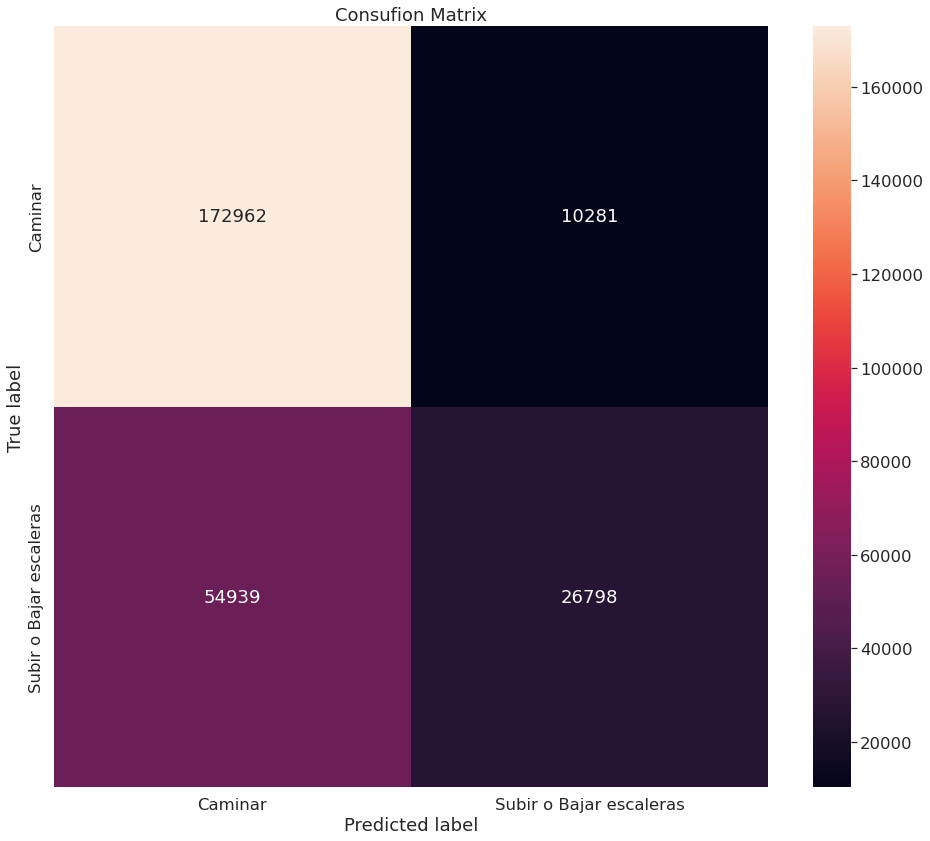

In [54]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [55]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 183243, Actividad: Caminar
Valor: 1, Cantidad: 81737, Actividad: Subir o Bajar escaleras


# Exportamos el modelo

In [56]:
import joblib
# Guardamos el modelo entrenado
filename = 'Modelos/model_USC-HAD.pkl' # Nombre del archivo donde se guardará el modelo
joblib.dump(model, filename) # Guardamos el modelo en un archivo
joblib.dump(label_encoder, 'Label/label_encoder_USC-HAD.pkl')  # Guardar el LabelEncoder

['Label/label_encoder_USC-HAD.pkl']